In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from consts import *

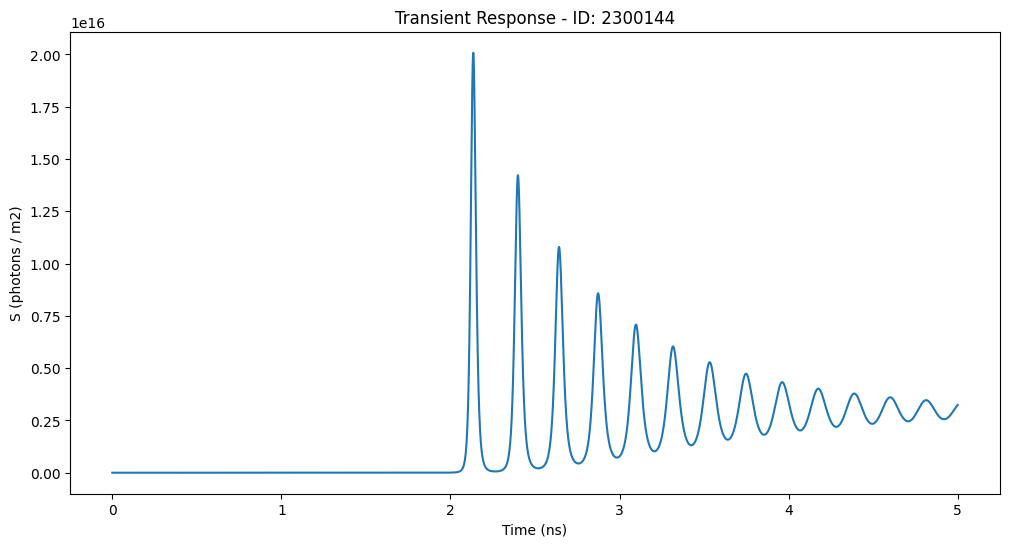

In [13]:
# define input current 
I_input = 50e-3

def dydt(y,t,current):
    N, S = y
    gain = B * max(N - N0, 0)
    injection =current/(q*V)
    dndt =injection-(N/TAU)-GAMMA*vg*gain*S
    dsdt = GAMMA*vg*gain*S-(S/tau_ph)+(BETA_SP* N /TAU)

    return [dndt, dsdt]

t1=np.linspace(0,1e-9,2000)
t2=np.linspace(1e-9,5e-9,10000)
initial_conditions_1 =[0,0]
soln1= odeint(dydt, initial_conditions_1,t1, args=(0.0,))
initial_conditions_2 =soln1[-1,:]
soln2=odeint(dydt, initial_conditions_2,t2,args=(I_input,))
t_total= np.concatenate((t1, t2))
soln_total= np.vstack((soln1, soln2))
N_t=soln_total[:,0]
S_t=soln_total[:,1]

plt.figure(figsize=(12, 6))
plt.plot(t_total*1e9, S_t)
plt.xlabel("Time (ns)")
plt.ylabel("S (photons / m2)")
plt.title("Transient Response - ID: 2300144")
plt.show()